# FEMALE LABOUR FORCE PARTICIPATION: A STATE-LEVEL REGRESSION ANALYSIS

## PROBLEM STATEMENT

- India's female Labour Force Participation Rate (LFPR) varies dramatically across states —
  from as low as 10.4% to as high as 53.4% (PLFS 2025) — despite decades of national-level
  policy attention to women's workforce participation.
- This wide variation suggests that state-specific structural factors, rather than
  a single national trend, are driving whether women enter the workforce.
- This analysis investigates two commonly cited structural explanations: **female education levels** and **state-     level income/economic development** — to test whether either (or both) is statistically associated with a state's   female LFPR, as often conventionally assumped.

## OBJECTIVE

- Quantify the statistical relationship between a state's Combined Female LFPR and two predictors: **Female           Literacy Rate** and **Per Capita NSDP**.
- Test whether female literacy and per-capita state income show a statistically meaningful relationship with it, at   the state level.
- Translate the regression findings into policy-relevant takeaways — i.e., does the evidence point toward             education-focused interventions, income/economic-growth focused interventions, or both, as levers for improving     female workforce participation.

## DATA SOURCES

- **Labour Force Participation Rate (LFPR):** Periodic Labour Force Survey (PLFS)
  Annual Report 2025, Ministry of Statistics and Programme Implementation (MoSPI).
- **Female Literacy Rate:** PLFS Annual Report 2025, Table 7 (Appendix A) — rural +
  urban combined, age 7 years & above.
- **Per Capita Net State Domestic Product (NSDP):** RBI Handbook of Statistics on
  Indian States, Table 20 — constant prices, base year 2011-12, reference year
  2022-23 (most recent year with complete state-level coverage).
- **Scope:** 28 states + Delhi (NCT).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

## STEP 1: Reading and Understanding the Data

In [2]:
plfs_data = pd.read_excel("PLFS_ANALYSIS.xlsx", sheet_name="Master")

In [3]:
plfs_data.shape

(29, 33)

In [4]:
plfs_data.head(10)

,STATE,RURAL MALE,RURAL FEMALE,RURAL PERSONS,RURAL MALE-FEMALE GAP,URBAN MALE,URBAN FEMALE,URBAN PERSONS,URBAN MALE-FEMALE GAP,RURAL-URBAN GAP (MALE),...,RANK RURAL-URBAN GAP,RANK COMBINED MALE-FEMALE GAP,RANK FEMALE-MALE LFPR %,FEMALE LITERACY RATE,PER CAPITA NSDP,AGRI SHARE %,INDUSTRY SHARE %,SERVICES SHARE %,CHECK SUM (should = 100),DATA NOTES
0,Andhra Pradesh,64.0,40.8,52.0,23.2,58.8,26.9,42.4,31.9,5.2,...,9,20,16,65.5,123853,15.74,32.82,51.44,100.00,NaN
1,Arunachal Pradesh,59.9,48.7,54.5,11.2,60.7,31.8,46.4,28.9,-0.8,...,17,31,6,81.6,106512,14.28,24.67,61.05,100.00,NaN
2,Assam,59.9,33.2,46.5,26.7,62.6,23.9,42.9,38.7,-2.7,...,24,14,21,85.0,71551,16.83,47.71,35.46,100.00,NaN
3,Bihar,49.0,17.7,33.1,31.3,50.0,10.2,31.1,39.8,-1.0,...,28,9,33,65.5,30678,10.71,27.36,61.92,99.99,NaN
4,Chhattisgarh,64.6,51.4,58.0,13.2,62.3,26.2,44.3,36.1,2.3,...,2,27,8,74.2,82699,11.82,51.43,36.75,100.00,NaN
5,Delhi,53.4,8.1,32.6,45.3,56.2,10.5,34.9,45.7,-2.8,...,35,1,36,84.4,252768,0.03,13.85,86.12,100.00,NaN
6,Goa,61.8,22.2,42.1,39.6,63.6,23.5,44.3,40.1,-1.8,...,34,3,32,88.6,333709,2.05,60.70,37.24,99.99,NaN
7,Gujarat,64.8,42.9,53.9,21.9,63.5,25.9,45.7,37.6,1.3,...,16,15,18,77.4,181963,9.73,51.02,39.24,99.99,NaN
8,Haryana,55.6,20.4,38.7,35.2,58.3,15.8,38.3,42.5,-2.7,...,31,4,34,76.8,171661,8.06,35.46,56.48,100.00,NaN
9,Himachal Pradesh,65.7,55.4,60.4,10.3,62.1,32.8,48.2,29.3,3.6,...,3,33,4,85.9,144824,5.23,51.76,43.00,99.99,NaN


In [5]:
plfs_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   STATE                          29 non-null     object 
 1   RURAL MALE                     29 non-null     float64
 2   RURAL FEMALE                   29 non-null     float64
 3   RURAL PERSONS                  29 non-null     float64
 4   RURAL MALE-FEMALE GAP          29 non-null     float64
 5   URBAN MALE                     29 non-null     float64
 6   URBAN FEMALE                   29 non-null     float64
 7   URBAN PERSONS                  29 non-null     float64
 8   URBAN MALE-FEMALE GAP          29 non-null     float64
 9   RURAL-URBAN GAP (MALE)         29 non-null     float64
 10  RURAL-URBAN GAP (FEMALE)       29 non-null     float64
 11  RURAL-URBAN GAP (PERSONS)      29 non-null     float64
 12  COMBINED MALE                  29 non-null     float

In [6]:
plfs_data.drop(["CHECK SUM (should = 100)", "DATA NOTES"], axis = 1, inplace = True)

In [7]:
plfs_data.shape

(29, 31)

In [8]:
plfs_data.head()

,STATE,RURAL MALE,RURAL FEMALE,RURAL PERSONS,RURAL MALE-FEMALE GAP,URBAN MALE,URBAN FEMALE,URBAN PERSONS,URBAN MALE-FEMALE GAP,RURAL-URBAN GAP (MALE),...,RANK RURAL MALE-FEMALE GAP,RANK URBAN MALE-FEMALE GAP,RANK RURAL-URBAN GAP,RANK COMBINED MALE-FEMALE GAP,RANK FEMALE-MALE LFPR %,FEMALE LITERACY RATE,PER CAPITA NSDP,AGRI SHARE %,INDUSTRY SHARE %,SERVICES SHARE %
0,Andhra Pradesh,64.0,40.8,52.0,23.2,58.8,26.9,42.4,31.9,5.2,...,17,22,9,20,16,65.5,123853,15.74,32.82,51.44
1,Arunachal Pradesh,59.9,48.7,54.5,11.2,60.7,31.8,46.4,28.9,-0.8,...,30,30,17,31,6,81.6,106512,14.28,24.67,61.05
2,Assam,59.9,33.2,46.5,26.7,62.6,23.9,42.9,38.7,-2.7,...,10,12,24,14,21,85.0,71551,16.83,47.71,35.46
3,Bihar,49.0,17.7,33.1,31.3,50.0,10.2,31.1,39.8,-1.0,...,7,11,28,9,33,65.5,30678,10.71,27.36,61.92
4,Chhattisgarh,64.6,51.4,58.0,13.2,62.3,26.2,44.3,36.1,2.3,...,28,18,2,27,8,74.2,82699,11.82,51.43,36.75


In [9]:
plfs_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   STATE                          29 non-null     object 
 1   RURAL MALE                     29 non-null     float64
 2   RURAL FEMALE                   29 non-null     float64
 3   RURAL PERSONS                  29 non-null     float64
 4   RURAL MALE-FEMALE GAP          29 non-null     float64
 5   URBAN MALE                     29 non-null     float64
 6   URBAN FEMALE                   29 non-null     float64
 7   URBAN PERSONS                  29 non-null     float64
 8   URBAN MALE-FEMALE GAP          29 non-null     float64
 9   RURAL-URBAN GAP (MALE)         29 non-null     float64
 10  RURAL-URBAN GAP (FEMALE)       29 non-null     float64
 11  RURAL-URBAN GAP (PERSONS)      29 non-null     float64
 12  COMBINED MALE                  29 non-null     float

In [10]:
plfs_data.dtypes.value_counts()

float64    21
int64       9
object      1
dtype: int64

In [11]:
plfs_data.describe()

,RURAL MALE,RURAL FEMALE,RURAL PERSONS,RURAL MALE-FEMALE GAP,URBAN MALE,URBAN FEMALE,URBAN PERSONS,URBAN MALE-FEMALE GAP,RURAL-URBAN GAP (MALE),RURAL-URBAN GAP (FEMALE),...,RANK RURAL MALE-FEMALE GAP,RANK URBAN MALE-FEMALE GAP,RANK RURAL-URBAN GAP,RANK COMBINED MALE-FEMALE GAP,RANK FEMALE-MALE LFPR %,FEMALE LITERACY RATE,PER CAPITA NSDP,AGRI SHARE %,INDUSTRY SHARE %,SERVICES SHARE %
count,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,...,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.00000,29.000000
mean,59.555172,37.568966,48.593103,21.986207,58.686207,24.879310,42.096552,33.806897,0.868966,12.689655,...,18.103448,18.206897,17.965517,18.965517,18.034483,80.148276,127776.000000,10.276552,34.84931,54.872414
std,5.399642,12.105285,7.777850,9.975639,4.397298,7.867945,4.339395,8.801904,2.782099,8.538666,...,10.132497,10.479161,10.890634,10.171679,10.293836,9.300600,71087.868446,6.150935,14.19288,14.023430
min,49.000000,8.100000,32.600000,3.600000,47.000000,10.200000,31.100000,11.900000,-2.800000,-2.400000,...,2.000000,1.000000,1.000000,1.000000,1.000000,63.700000,30678.000000,0.030000,10.59000,27.740000
25%,55.600000,32.500000,44.300000,14.400000,56.800000,21.100000,40.100000,29.400000,-1.700000,7.500000,...,9.000000,10.000000,9.000000,11.000000,10.000000,74.200000,71551.000000,5.880000,26.04000,43.000000
50%,60.300000,39.400000,49.700000,22.200000,59.800000,25.300000,42.800000,36.100000,1.100000,13.900000,...,19.000000,18.000000,18.000000,19.000000,18.000000,80.700000,123853.000000,9.730000,31.62000,55.670000
75%,64.000000,44.800000,52.300000,27.600000,62.100000,29.600000,44.500000,39.900000,3.000000,18.700000,...,26.000000,27.000000,27.000000,27.000000,25.000000,85.900000,163205.000000,14.280000,48.48000,67.330000
max,70.200000,61.600000,66.300000,45.300000,64.800000,40.700000,48.200000,45.700000,7.300000,28.100000,...,35.000000,36.000000,35.000000,36.000000,36.000000,99.800000,333709.000000,30.100000,66.38000,86.120000


In [12]:
plfs_data.isnull().sum()

STATE                            0
RURAL MALE                       0
RURAL FEMALE                     0
RURAL PERSONS                    0
RURAL MALE-FEMALE GAP            0
URBAN MALE                       0
URBAN FEMALE                     0
URBAN PERSONS                    0
URBAN MALE-FEMALE GAP            0
RURAL-URBAN GAP (MALE)           0
RURAL-URBAN GAP (FEMALE)         0
RURAL-URBAN GAP (PERSONS)        0
COMBINED MALE                    0
COMBINED FEMALE                  0
COMBINED PERSONS                 0
COMBINED MALE-FEMALE GAP         0
FEMALE-TO-MALE LFPR RATIO        0
FEMALE-TO-MALE LFPR %            0
RANK COMBINED PERSONS            0
RANK COMBINED FEMALE             0
RANK COMBINED MALE               0
RANK RURAL MALE-FEMALE GAP       0
RANK URBAN MALE-FEMALE GAP       0
RANK RURAL-URBAN GAP             0
RANK COMBINED MALE-FEMALE GAP    0
RANK FEMALE-MALE LFPR %          0
FEMALE LITERACY RATE             0
PER CAPITA NSDP                  0
AGRI SHARE %        

In [13]:
plfs_data.nunique()

STATE                            29
RURAL MALE                       27
RURAL FEMALE                     29
RURAL PERSONS                    27
RURAL MALE-FEMALE GAP            28
URBAN MALE                       27
URBAN FEMALE                     28
URBAN PERSONS                    26
URBAN MALE-FEMALE GAP            27
RURAL-URBAN GAP (MALE)           28
RURAL-URBAN GAP (FEMALE)         29
RURAL-URBAN GAP (PERSONS)        27
COMBINED MALE                    26
COMBINED FEMALE                  28
COMBINED PERSONS                 29
COMBINED MALE-FEMALE GAP         27
FEMALE-TO-MALE LFPR RATIO        29
FEMALE-TO-MALE LFPR %            29
RANK COMBINED PERSONS            29
RANK COMBINED FEMALE             28
RANK COMBINED MALE               26
RANK RURAL MALE-FEMALE GAP       28
RANK URBAN MALE-FEMALE GAP       28
RANK RURAL-URBAN GAP             27
RANK COMBINED MALE-FEMALE GAP    27
RANK FEMALE-MALE LFPR %          29
FEMALE LITERACY RATE             28
PER CAPITA NSDP             

In [14]:
plfs_data.duplicated().sum()

0

#### OBSERVATIONS

- After dropping the two validation-only columns (CHECK SUM, DATA NOTES — used earlier to
  verify the RBI merge, not needed for analysis), the dataset has 29 rows and 31 columns.
- No missing values in any column (`isnull().sum()` returns 0 across the board).
- No duplicate rows (`duplicated().sum()` = 0).
- Data types are clean: 21 float64, 9 int64, and 1 object (STATE). Thus, no type conversion needed before analysis.
- `nunique()` confirms STATE has exactly 29 unique values. 

## STEP 2: Univariate Analysis

In [15]:
def plot_distribution(df, col):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.histplot(df[col], kde=True, bins=8, edgecolor='black', ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')
    
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()

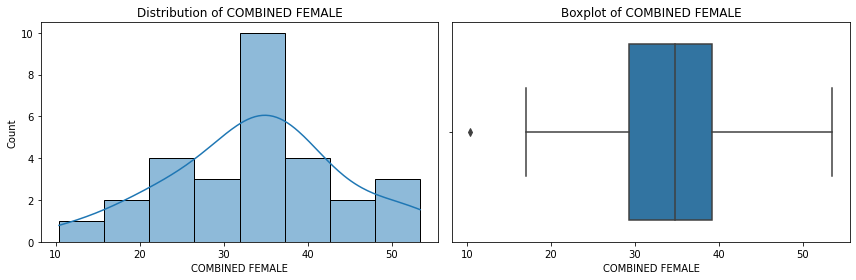

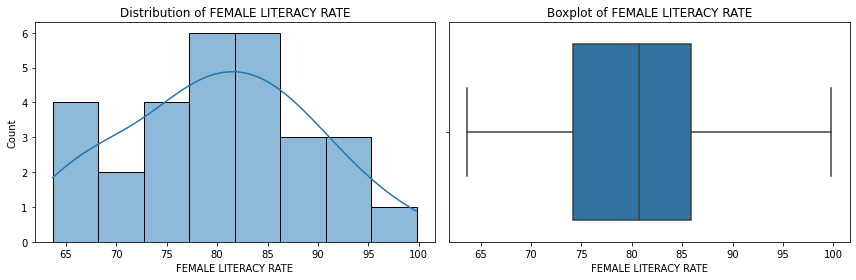

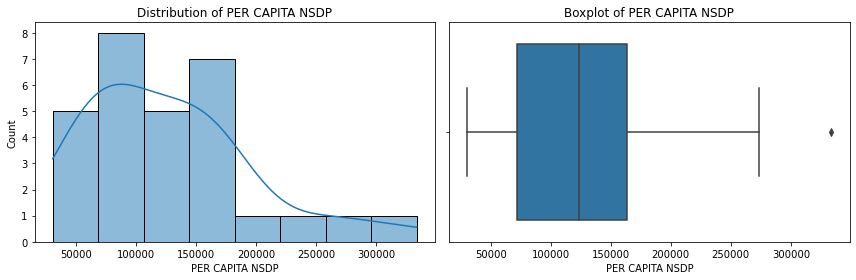

In [16]:
uni_vars = ['COMBINED FEMALE', 'FEMALE LITERACY RATE', 'PER CAPITA NSDP']

for col in uni_vars:
    plot_distribution(plfs_data, col)

In [17]:
def top_bottom_states(df, col, n=5):
    top = df.nlargest(n, col)[['STATE', col]]
    bottom = df.nsmallest(n, col)[['STATE', col]]
    return top, bottom

In [18]:
top5, bottom5 = top_bottom_states(plfs_data, 'COMBINED FEMALE')
print(top5)
print(bottom5)

                STATE  COMBINED FEMALE
22             Sikkim             53.4
9    Himachal Pradesh             52.6
18           Nagaland             50.9
4        Chhattisgarh             46.4
1   Arunachal Pradesh             45.6
            STATE  COMBINED FEMALE
5           Delhi             10.4
3           Bihar             17.0
8         Haryana             18.4
6             Goa             23.0
27  Uttar Pradesh             23.7


In [19]:
def plot_top_bottom(plfs_data, col, n=5):
    top, bottom = top_bottom_states(plfs_data, col, n)
    combined = pd.concat([top, bottom])
    
    plt.figure(figsize=(8, 6))
    colors = ['#2E7D32']*n + ['#C62828']*n
    sns.barplot(data=combined, y='STATE', x=col, palette=colors)
    plt.title(f'Top {n} and Bottom {n} States — {col}')
    plt.tight_layout()
    plt.show()

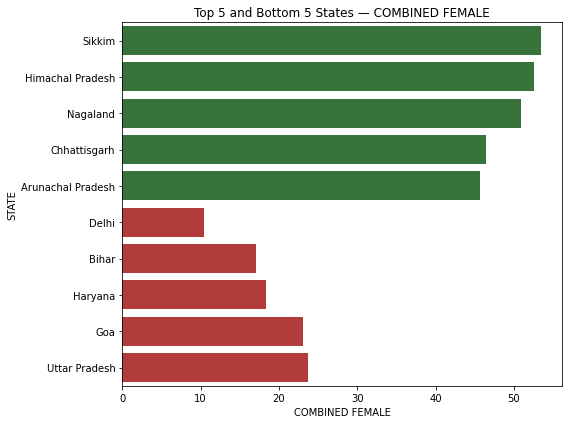

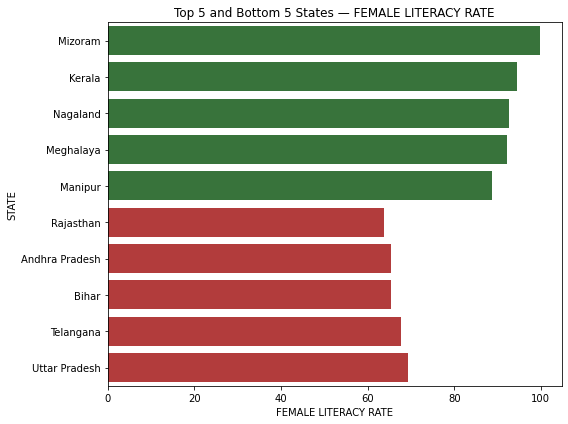

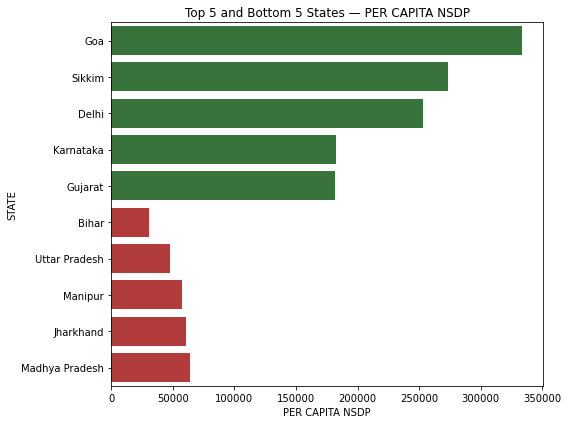

In [20]:
for col in uni_vars:
    plot_top_bottom(plfs_data, col)

#### OBSERVATIONS

**Distributions:**
- Combined Female LFPR is roughly bell-shaped and one low outlier, relative to the bulk of states clustered in the   30-40% range.
- Female Literacy Rate is fairly spread out (63.7% to 99.8%), with a cluster of states in the
  75-85% band.
- Per Capita NSDP is right-skewed, for an income-type variable, most states cluster
  under ₹150,000, with a small number of high-income states (Goa, Delhi, Sikkim) pulling the tail
  right.

**Rankings:**
- A consistent group of hilly and North-Eastern states such as, Sikkim, Himachal Pradesh,
  Nagaland, Arunachal Pradesh, Meghalaya, repeatedly appears at the TOP for both Female LFPR
  and gender-parity indicators (lowest Male-Female Gap, highest Female-to-Male LFPR %). These
  states combine high female workforce participation with comparatively small gender gaps.
- Conversely, Delhi, Haryana, Punjab, Goa, and Bihar repeatedly appear at the BOTTOM for female
  LFPR and gender parity — but several of these (Delhi, Goa, Punjab) are simultaneously among the
  TOP states for Per Capita NSDP. This is a notable insight as higher state income does not, on its own, appear to   relate with higher female workforce participation.

## STEP 3: Bivariate Analysis

In [22]:
corr_literacy = plfs_data['FEMALE LITERACY RATE'].corr(plfs_data['COMBINED FEMALE'])
corr_nsdp = plfs_data['PER CAPITA NSDP'].corr(plfs_data['COMBINED FEMALE'])

print(f"Correlation (Female Literacy vs Female LFPR): {corr_literacy:.3f}")
print(f"Correlation (Per Capita NSDP vs Female LFPR): {corr_nsdp:.3f}")

Correlation (Female Literacy vs Female LFPR): 0.149
Correlation (Per Capita NSDP vs Female LFPR): -0.133


In [23]:
from scipy.stats import pearsonr

r_lit, p_lit = pearsonr(plfs_data['FEMALE LITERACY RATE'], plfs_data['COMBINED FEMALE'])
r_nsdp, p_nsdp = pearsonr(plfs_data['PER CAPITA NSDP'], plfs_data['COMBINED FEMALE'])

print(f"Literacy: r = {r_lit:.3f}, p = {p_lit:.3f}")
print(f"NSDP:     r = {r_nsdp:.3f}, p = {p_nsdp:.3f}")

Literacy: r = 0.149, p = 0.441
NSDP:     r = -0.133, p = 0.491


In [24]:
def plot_scatter(df, x_col, y_col):
    plt.figure(figsize=(8, 6))
    
    sns.regplot(data=df, x=x_col, y=y_col, 
                scatter_kws={'alpha':0.7, 's':80}, 
                line_kws={'color':'red'})
    
    plt.title(f'{y_col} vs {x_col}')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()

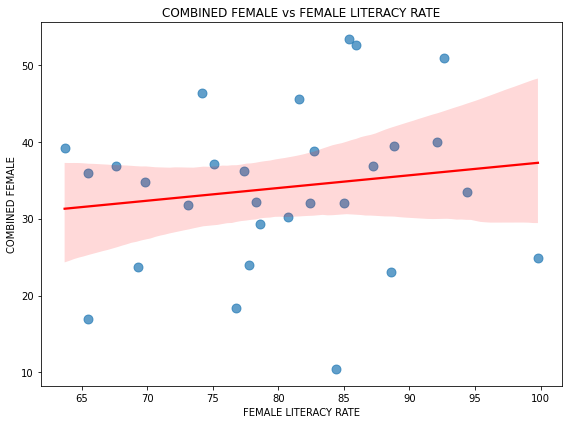

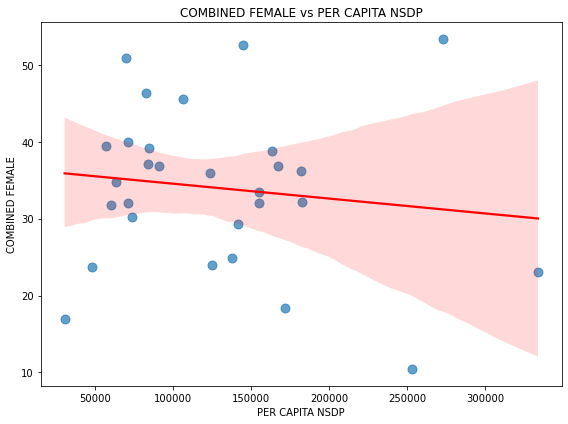

In [25]:
plot_scatter(plfs_data, 'FEMALE LITERACY RATE', 'COMBINED FEMALE')
plot_scatter(plfs_data, 'PER CAPITA NSDP', 'COMBINED FEMALE')

 #### OBSERVATIONS

- Female Literacy Rate shows a weak positive correlation with Combined Female LFPR
  (r = 0.149), and Per Capita NSDP shows a weak negative correlation (r = -0.133).
- Critically, NEITHER correlation is statistically significant at conventional thresholds
  (Literacy: p = 0.441; NSDP: p = 0.491 — both far above the p < 0.05 cutoff). With a sample
  of 29 states, this means these weak correlations are consistent with random variation and
  cannot be confidently distinguished from "no relationship at all" based on this evidence.
- This is a meaningful finding in its own right: it pushes back against the common assumption
  that female workforce participation is primarily driven by education or income levels.
  Neither factor shows a detectable linear relationship with Female LFPR in this dataset,
  suggesting other factors — social norms, sector composition of state economies, availability
  of specific types of work — likely play a larger role.
- The direction of the NSDP correlation (negative) is still worth noting narratively, given it
  aligns with the univariate finding that high-income states (Delhi, Goa, Punjab) cluster at
  the bottom of the Female LFPR rankings — but the lack of statistical significance means this
  should be framed as an observed pattern worth further investigation, not a confirmed effect.

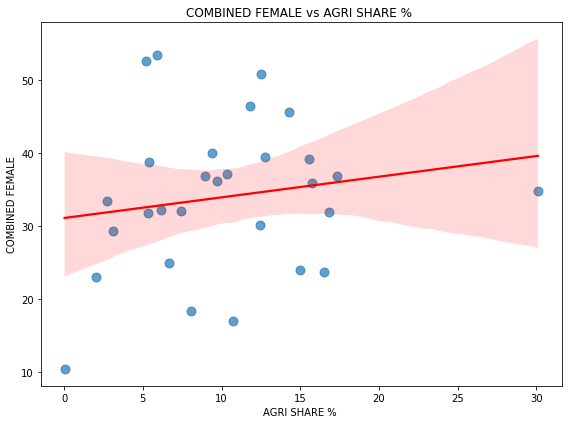

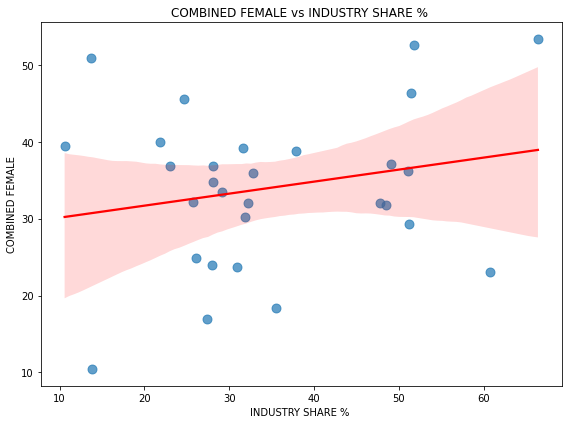

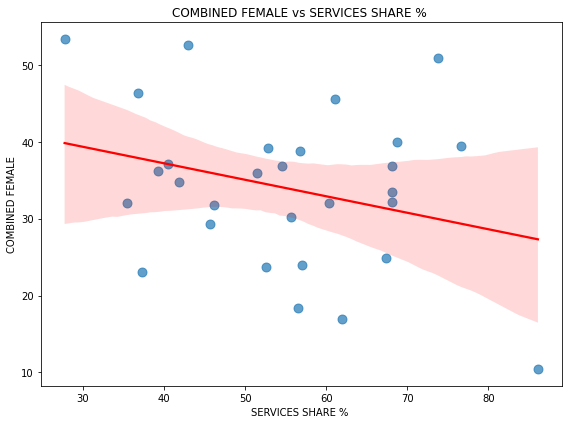

AGRI SHARE % : r = 0.168, p = 0.384
INDUSTRY SHARE % : r = 0.215, p = 0.264
SERVICES SHARE % : r = -0.291, p = 0.126



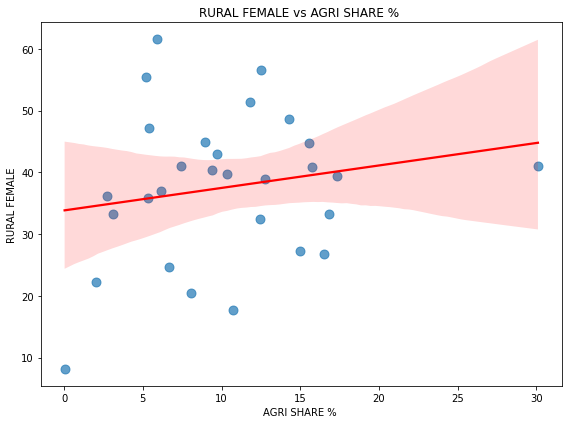

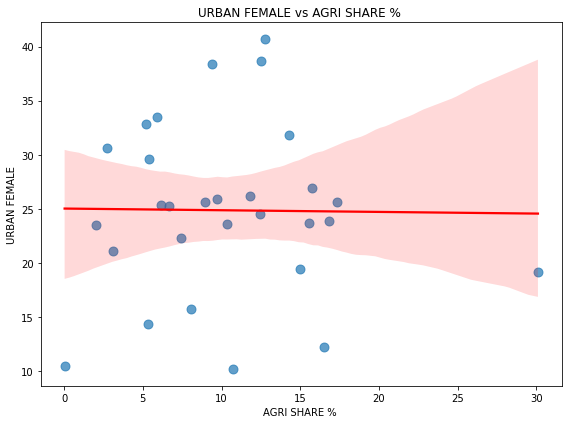

Agri Share vs Rural Female LFPR: r = 0.185, p = 0.337
Agri Share vs Urban Female LFPR: r = -0.012, p = 0.950


In [26]:
sector_vars = ['AGRI SHARE % ', 'INDUSTRY SHARE % ', 'SERVICES SHARE % '] 

for col in sector_vars:
    plot_scatter(plfs_data, col, 'COMBINED FEMALE')

for col in sector_vars:
    r, p = pearsonr(plfs_data[col], plfs_data['COMBINED FEMALE'])
    print(f"{col}: r = {r:.3f}, p = {p:.3f}")

print()

plot_scatter(plfs_data, sector_vars[0], 'RURAL FEMALE')
plot_scatter(plfs_data, sector_vars[0], 'URBAN FEMALE')

r_rural, p_rural = pearsonr(plfs_data[sector_vars[0]], plfs_data['RURAL FEMALE'])
r_urban, p_urban = pearsonr(plfs_data[sector_vars[0]], plfs_data['URBAN FEMALE'])
print(f"Agri Share vs Rural Female LFPR: r = {r_rural:.3f}, p = {p_rural:.3f}")
print(f"Agri Share vs Urban Female LFPR: r = {r_urban:.3f}, p = {p_urban:.3f}")

#### OBSERVATIONS

**Sector composition (Agri/Industry/Services shares):**
- All three sector shares show weak, non-significant correlations with Combined Female LFPR
  (Agri: r = 0.168, p = 0.384; Industry: r = 0.215, p = 0.264; Services: r = -0.291, p = 0.126).
  Services showed the strongest (though still weak) relationship, and its negative direction is
  broadly consistent with the earlier finding that more urbanized, services-heavy states (Delhi,
  Goa, Punjab) tend toward lower female LFPR.
- Splitting Agri Share against Rural vs Urban Female LFPR specifically showed a sensible pattern:
  a small positive association with Rural Female LFPR (r = 0.185, p = 0.337) and essentially zero
  association with Urban Female LFPR (r = -0.012, p = 0.950) — as expected, since agricultural
  work is inherently rural. 

## STEP 4: Multivariate Analysis

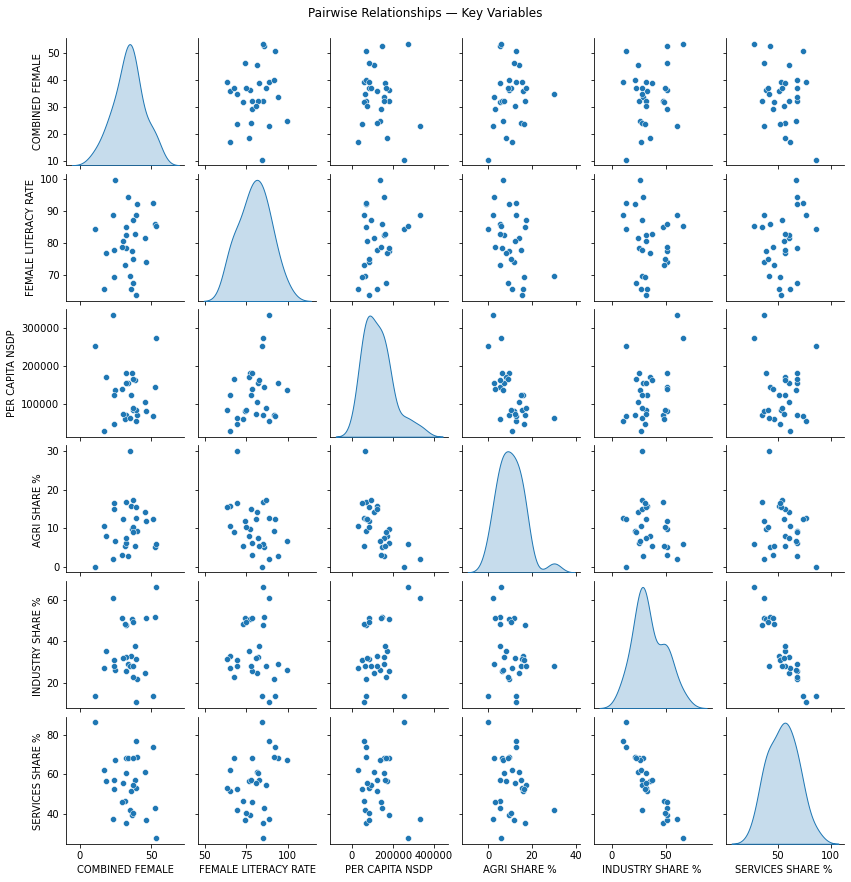

In [27]:
key_vars = ['COMBINED FEMALE', 'FEMALE LITERACY RATE', 'PER CAPITA NSDP', 
            'AGRI SHARE % ', 'INDUSTRY SHARE % ', 'SERVICES SHARE % ']

sns.pairplot(plfs_data[key_vars], diag_kind='kde', height=2)
plt.suptitle('Pairwise Relationships — Key Variables', y=1.02)
plt.show()

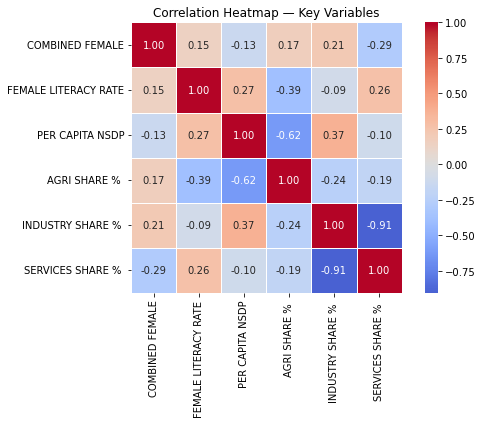

In [28]:
plt.figure(figsize=(8, 6))
corr_matrix = plfs_data[key_vars].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Key Variables')
plt.tight_layout()
plt.show()

#### OBSERVATIONS

- The correlation heatmap reveals a much stronger relationship than any found in the bivariate
  step: INDUSTRY SHARE % and SERVICES SHARE % are almost perfectly negatively correlated
  (r = -0.91). This reflects the near-zero-sum nature of sectoral composition — states with a
  larger industrial base necessarily have a smaller services base, and vice versa, since these
  two sectors make up the bulk of most state economies. This confirms that Industry and Services
  share cannot be meaningfully treated as independent variables in a combined model.
- PER CAPITA NSDP and AGRI SHARE % show a moderate-to-strong negative correlation (r = -0.62) —
  richer states tend to have meaningfully smaller agricultural sectors, consistent with typical
  patterns of economic development shifting activity away from agriculture.
- The two variables selected for the regression model — FEMALE LITERACY RATE and PER
  CAPITA NSDP — show only a weak correlation with each other (r = 0.27). Thus, multicollinearity between the         regression's two predictors is unlikely to be a serious concern.

## STEP 5: Multicollinearity Check (VIF)

In [30]:
from statsmodels.tools.tools import add_constant

X = plfs_data[['FEMALE LITERACY RATE', 'PER CAPITA NSDP']]
X_const = add_constant(X)

vif_data = pd.DataFrame()
vif_data['Variable'] = X_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

print(vif_data)

NameError: name 'variance_inflation_factor' is not defined

#### OBSERVATIONS

- VIF for FEMALE LITERACY RATE and PER CAPITA NSDP both came out at 1.08. This confirms, more rigorously than the     correlation coefficient, that multicollinearity is not a problem for this regression.

## STEP 6: Regression Analysis

In [31]:
import statsmodels.api as sm

X = plfs_data[['FEMALE LITERACY RATE', 'PER CAPITA NSDP']]
X = sm.add_constant(X)
Y = plfs_data['COMBINED FEMALE']

model = sm.OLS(Y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        COMBINED FEMALE   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                 -0.018
Method:                 Least Squares   F-statistic:                    0.7527
Date:                Wed, 26 Aug 2026   Prob (F-statistic):              0.481
Time:                        15:19:39   Log-Likelihood:                -107.59
No. Observations:                  29   AIC:                             221.2
Df Residuals:                      26   BIC:                             225.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   19.6785 

#### OBSERVATIONS

This regression directly tests the conventional assumption stated in the Problem Statement: that literacy and income are often assumed to be meaningful drivers of female LFPR. However, the results do not support it.

- The regression model explains essentially none of the variation in Combined Female LFPR
  (R² = 0.055; Adjusted R² = -0.018), and the model as a whole is not statistically significant
  (F-statistic p = 0.481). Neither Female Literacy Rate (p = 0.322) nor Per Capita NSDP
  (p = 0.352) is individually significant either.
- This confirms, with full regression rigor, what the bivariate and multivariate analyses
  already suggested: female literacy and state economic development, whether examined
  individually or jointly, do not meaningfully explain the wide variation in female LFPR across
  Indian states in this dataset.
- This is a substantively important finding for the policy narrative: it directly challenges the
  common assumption that improving education or income alone will meaningfully close female
  workforce participation gaps. The consistent pattern across every method used here — states
  like Delhi, Goa, and Punjab combining high income/literacy with low female LFPR, while several
  North-Eastern and hill states show the reverse — points toward social, cultural, and
  structural labor-market factors (type of available work, norms around women's paid work,
  household composition) as more likely drivers, which fall outside what this dataset can
  directly measure.

## STEP 7: What Explains the Rural-Urban Gap in Female LFPR?

The main analysis (Steps 1-6) tested what explains the level of female LFPR, however, the two variables tested did not show any statistically significant insight. 

This section asks a related but distinct question: does anything explain how evenly that LFPR is split between a states' rural and urban areas? This uses the dependent variable : RURAL-URBAN GAP.

### Univariate Analysis : The Rural-Urban Gap


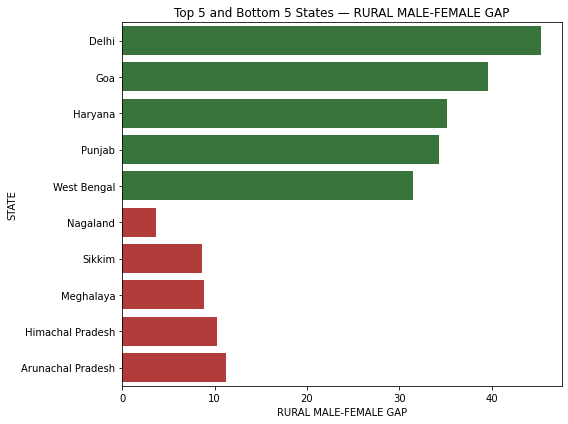

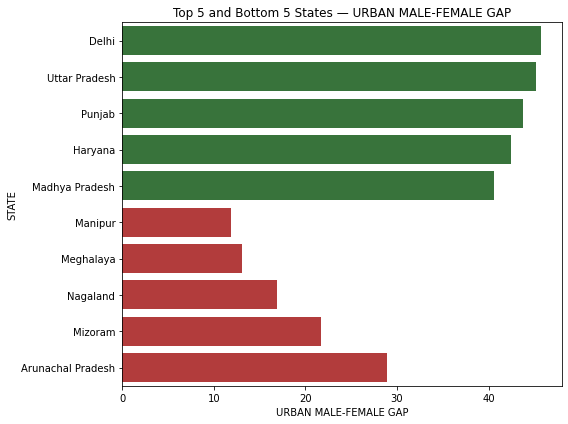

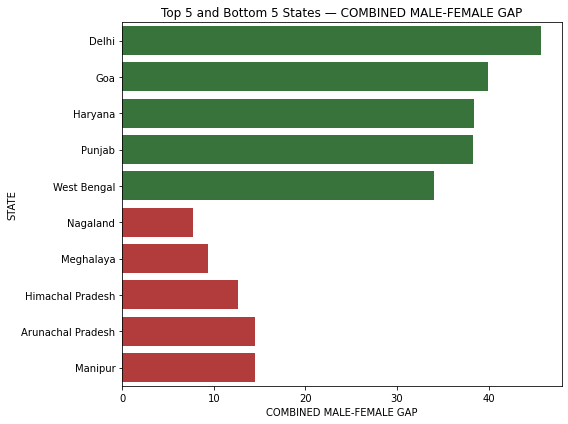

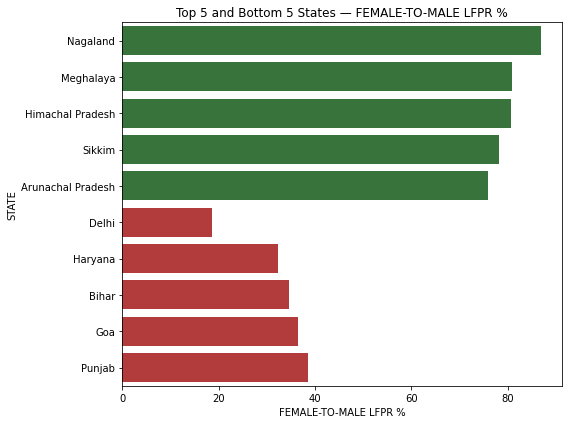

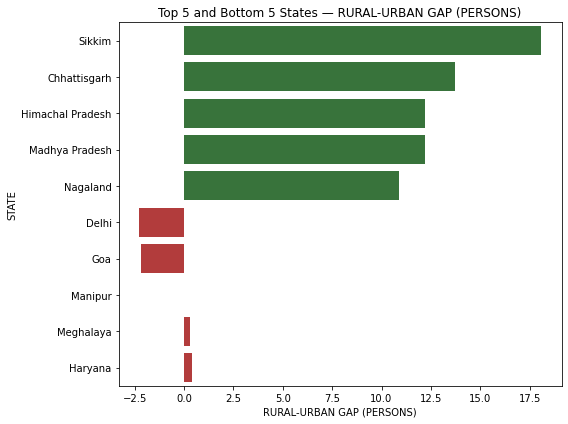

In [35]:
other_cols = ['RURAL MALE-FEMALE GAP', 'URBAN MALE-FEMALE GAP','COMBINED MALE-FEMALE GAP', 'FEMALE-TO-MALE LFPR %', 'RURAL-URBAN GAP (PERSONS)']

for col in other_cols:
    plot_top_bottom(plfs_data, col)

#### OBSERVATIONS:

- Delhi, Goa, Haryana, Punjab, West Bengal consistently show the largest combined gender gaps (rural, urban, and     combined).
- Nagaland, Meghalaya, Himachal Pradesh, Sikkim, Arunachal Pradesh consistently show the smallest gaps and the       highest Female-to-Male LFPR %.
- On Rural-Urban Gap (PERSONS): Sikkim, Chhattisgarh, Himachal Pradesh, Madhya Pradesh, Nagaland show the largest     rural-over-urban gaps; Delhi and Goa are the only states where it flips negative (urban exceeds rural).

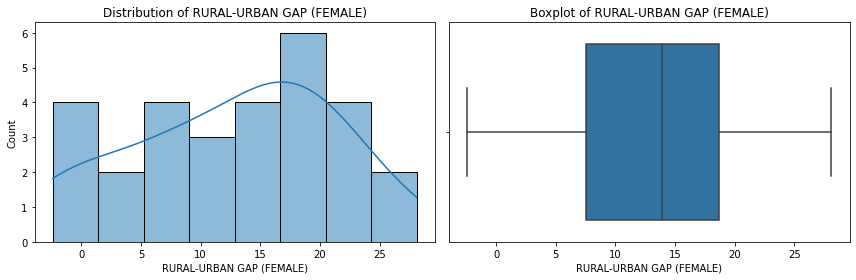

States with the LARGEST rural-urban gap (female):
                STATE  RURAL-URBAN GAP (FEMALE)
22            Sikkim                      28.1
4       Chhattisgarh                      25.2
9   Himachal Pradesh                      22.6
13    Madhya Pradesh                      21.9
10         Jharkhand                      21.4

States with the SMALLEST (or negative) rural-urban gap (female):
         STATE  RURAL-URBAN GAP (FEMALE)
5       Delhi                      -2.4
15    Manipur                      -1.8
6         Goa                      -1.3
17    Mizoram                      -0.7
16  Meghalaya                       1.9


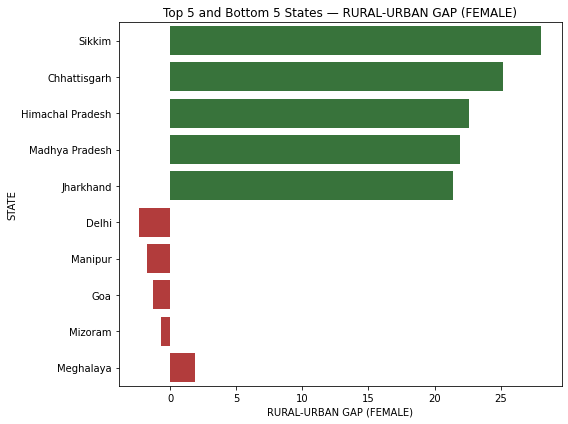

In [36]:
plot_distribution(plfs_data, 'RURAL-URBAN GAP (FEMALE)')

top5_gap, bottom5_gap = top_bottom_states(plfs_data, 'RURAL-URBAN GAP (FEMALE)')
print("States with the LARGEST rural-urban gap (female):\n", top5_gap)
print("\nStates with the SMALLEST (or negative) rural-urban gap (female):\n", bottom5_gap)

plot_top_bottom(plfs_data, 'RURAL-URBAN GAP (FEMALE)')

#### OBSERVATIONS

- The Rural-Urban Gap (Female LFPR) ranges from : 2.4 (Delhi) to 28.1 percentage points (Sikkim), with most states   showing a positive gap — rural female participation exceeds urban female participation in the majority of states.
- The distribution is fairly spread out with a mild peak around 15-20 points, and no extreme outliers distorting     the shape.
- Top 5 largest gaps: Sikkim (28.1), Chhattisgarh (25.2), Himachal Pradesh (22.6), Madhya Pradesh (21.9), Jharkhand   (21.4) represent states where rural female work participation substantially exceeds urban.
- Bottom 5 (smallest or negative gaps): Delhi (-2.4), Manipur (-1.8), Goa (-1.3), Mizoram (-0.7), Meghalaya (1.9),   represent highly urbanized economies, where urban and rural female participation are close to equal, or urban       participation exceeds rural.
- Notably, four of the five states with the LARGEST gap here (Sikkim, Himachal Pradesh, Madhya Pradesh, Jharkhand     and Chattisgarh) also ranked among the highest for overall Combined Female LFPR in the above analysis —             suggesting these states' high female LFPR is substantially rural-driven, not evenly spread across rural and urban   areas.

### Bivariate Analysis

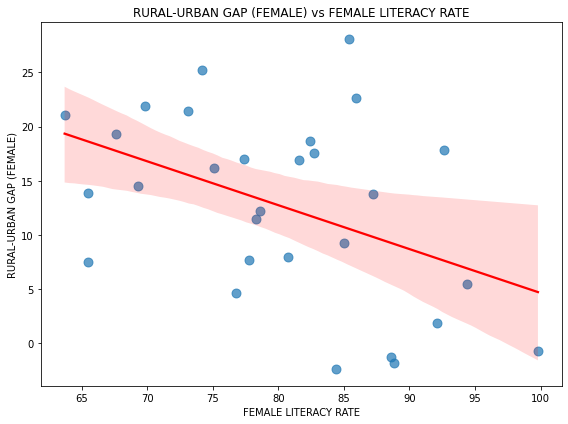

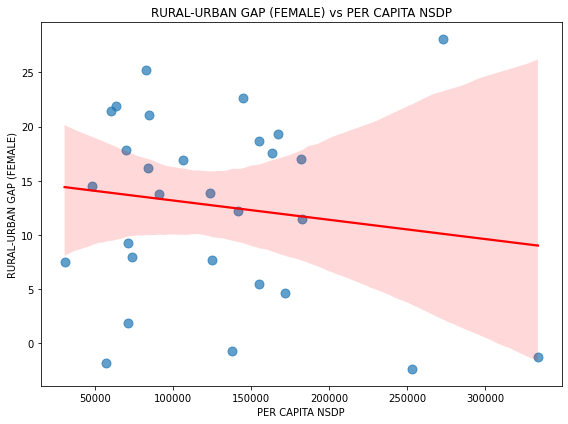

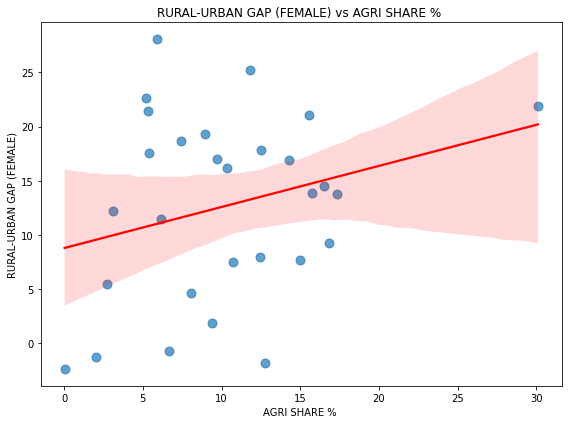

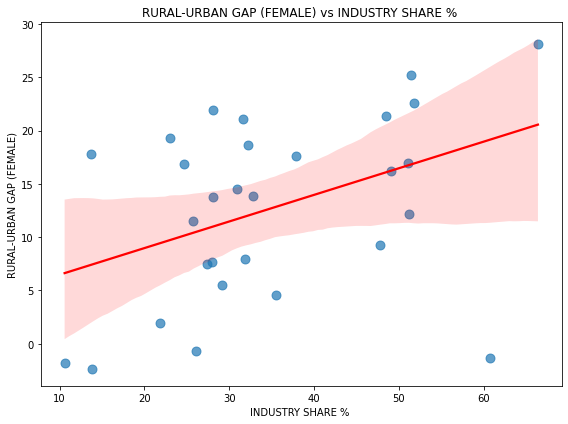

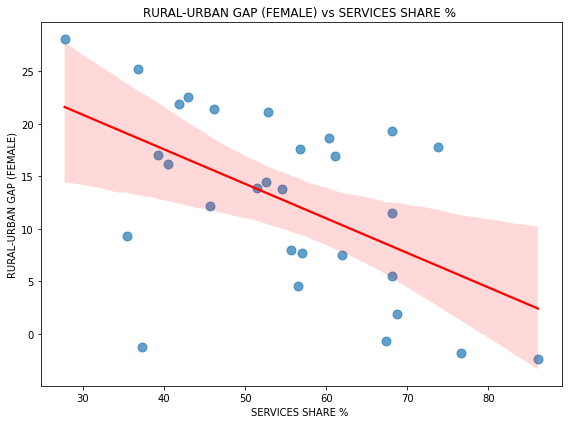

In [37]:
for var in gap_vars:
    plot_scatter(plfs_data, var, 'RURAL-URBAN GAP (FEMALE)')

#### OBSERVATION

- Visually, the Services Share and Female Literacy scatters show a clear downward-sloping trend line with points     clustered around it.
- The Industry Share scatter shows a clear upward slope. Per Capita NSDP and Agri Share show flat trend lines.

In [38]:
from statsmodels.stats.multitest import multipletests

reject, pvals_corrected, _, _ = multipletests(gap_results['p-value'], alpha=0.05, method='fdr_bh')

gap_results['p-value (corrected)'] = pvals_corrected.round(3)
gap_results['Still significant?'] = reject
print(gap_results)

               Variable      r  p-value  p-value (corrected)  \
4     SERVICES SHARE %  -0.540    0.002                0.010   
0  FEMALE LITERACY RATE -0.441    0.017                0.042   
3     INDUSTRY SHARE %   0.415    0.025                0.042   
2         AGRI SHARE %   0.273    0.151                0.189   
1       PER CAPITA NSDP -0.148    0.443                0.443   

   Still significant?  
4                True  
0                True  
3                True  
2               False  
1               False  


#### OBSERVATIONS

- Three variables show a statistically significant relationship with the rural-urban gap in female LFPR: Services     Share (r = -0.540, p = 0.002), Female Literacy (r = -0.441, p = 0.017), and Industry Share (r = 0.415, p =         0.025). Per Capita NSDP (p = 0.443) and Agri Share (p = 0.151) are not significant.
- States with a more services-oriented economy and higher female literacy show a smaller rural-urban gap. States     with a more industry-heavy economy show a larger gap.
- This mirrors the near-perfect negative correlation already found between industry and services share (r = -0.91),   the same underlying structural divide is surfacing here again.
- Unlike the regression results as shown in step 6, which found no significant predictors of the levels of female     LFPR, this analysis finds three significant predictors of how evenly that participation is distributed between     rural and urban areas.
- To address the multiple comparisons concern directly, p-values were corrected using the Benjamini-Hochberg (FDR)   procedure. All three findings rendered statistically significant after correction: Services Share (p = 0.010),     Female Literacy (p = 0.042), and Industry Share (p = 0.042). Agri Share (p = 0.189) and Per Capita NSDP (p =       0.443) remain non-significant. This confirms the three findings are not artifacts of testing multiple variables     at once.

## STEP 8: Policy Insights

Female LFPR varies enormously across states (10.4%–53.4%, PLFS 2025). This analysis set out to test a specific, widely-held assumption: that female literacy and state prosperity are the primary levers for closing India's female LFPR gap. Across every method used — bivariate correlation, multivariate analysis, and full regression — the data
does not support this assumption.

- Neither female literacy nor per-capita state income showed a statistically significant relationship with female     LFPR — individually, jointly, or across sector composition (regression R² = 0.055, not significant). If anything,   the pattern runs counter to expectations: Delhi, Goa, and Punjab — among India's richest states — rank near the     bottom for female LFPR, while lower-income states like Sikkim, Himachal Pradesh, and Nagaland rank near the top.

- This suggests the female LFPR gap is likely driven by factors outside income and education — social norms, the     type of work locally available, and household structures — rather than by access to education or economic growth   alone.
- Step 7 found a more nuanced picture: while literacy and economic structure don't explain the LEVEL of female       LFPR, they do show a statistically significant relationship with how evenly that participation is distributed       between rural and urban areas. States with a more services-oriented economy and higher female literacy show a
  smaller rural-urban gap; more industry-heavy states show a larger one.

This points toward a need to look at less conventionally measured factors — social norms, household and caregiving structures — for more likely explanations to explain policy insights in future. 